# RNA sequencing III

<a href="?print-pdf">print view</a>  
<a href="RNAseq-III.ipynb" download>notebook</a>

# Performance metrics
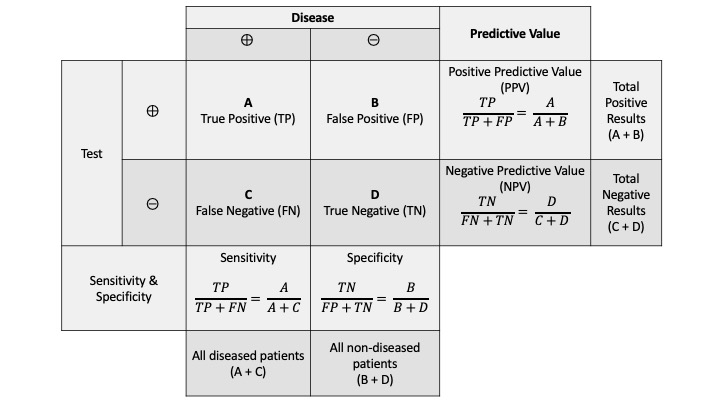

# Receiver Operator Characteristics (ROC)
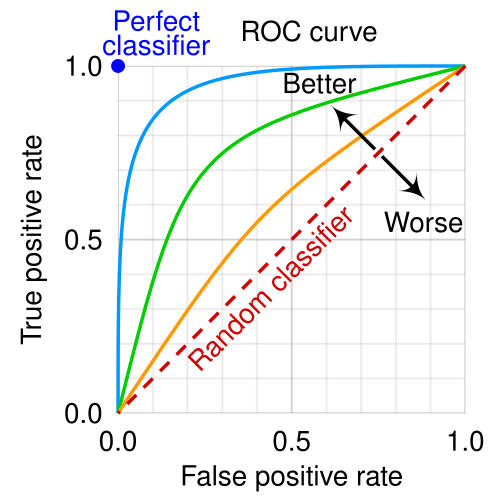

## Load data

We'll load the gene expression data where:
- **Rows** = Genes
- **Columns** = Samples (healthy and apoptotic)

In [53]:
import pandas as pd
import numpy as np
gene_df = pd.read_csv('https://mscbio2025-2025.github.io/files/data.csv',index_col=0);
gene_df.head()

,healthy_1,healthy_2,healthy_3,healthy_4,healthy_5,healthy_6,healthy_7,healthy_8,healthy_9,healthy_10,...,apoptotic_11,apoptotic_12,apoptotic_13,apoptotic_14,apoptotic_15,apoptotic_16,apoptotic_17,apoptotic_18,apoptotic_19,apoptotic_20
GAPDH,23,20,13,21,14,16,13,17,17,25,...,16,14,29,20,27,21,20,26,14,10
ACTB,18,24,22,18,25,19,23,13,16,15,...,10,20,12,25,16,16,15,20,10,14
RPL13A,15,22,16,18,19,26,17,20,21,37,...,28,26,21,18,16,15,40,18,25,21
EEF1A1,33,16,16,7,28,22,17,24,17,23,...,34,19,13,23,15,17,26,22,18,28
HPRT1,22,29,17,16,26,29,16,13,14,17,...,24,16,23,16,28,14,17,20,23,23


# QUIZ
- **We need to filter the data. Why?**
- **we need to normalize and variance stabilize the data. Why?**

In [ ]:
# Filtering
qc_filter = (gene_df > 10).sum(axis=1) >= 2
filtered_df = gene_df[qc_filter]

#====Normalization and Variance Stabilization
# Counts per Million normalization (Better approach TMM -- next time)
cpm = filtered_df.div(filtered_df.sum(axis=0), axis=1) * 1e6

# Variance stabilization (Better approach VST -- next time)
log_cpm = np.log2(cpm+1)

In [11]:
print(f"Original data shape: {log_cpm.shape}")
print(f"Number of genes: {log_cpm.shape[0]}")
print(f"Number of samples: {log_cpm.shape[1]}")

Original data shape: (22, 40)
Number of genes: 22
Number of samples: 40


In [12]:
# Separate healthy and apoptotic samples
healthy_cols = [col for col in log_cpm.columns if 'healthy' in col]
apoptotic_cols = [col for col in log_cpm.columns if 'apoptotic' in col]

print(f"\nHealthy samples: {len(healthy_cols)}")
print(f"Apoptotic samples: {len(apoptotic_cols)}")
print(f"\nGenes in dataset:")
print(log_cpm.index.tolist())

# Display first few rows
log_cpm.head()


Healthy samples: 20
Apoptotic samples: 20

Genes in dataset:
['GAPDH', 'ACTB', 'RPL13A', 'EEF1A1', 'HPRT1', 'CASP3', 'CASP8', 'BAX', 'BCL2', 'FAS', 'FASLG', 'XIAP', 'TRADD', 'TNFRSF10B', 'JAK1', 'JAK3', 'STAT4', 'IRF9', 'CHMP1A', 'CHMP5', 'IFNAR1', 'VDAC2']


,healthy_1,healthy_2,healthy_3,healthy_4,healthy_5,healthy_6,healthy_7,healthy_8,healthy_9,healthy_10,...,apoptotic_11,apoptotic_12,apoptotic_13,apoptotic_14,apoptotic_15,apoptotic_16,apoptotic_17,apoptotic_18,apoptotic_19,apoptotic_20
GAPDH,15.603410,15.482039,14.799169,15.595995,14.814161,15.210507,14.713199,15.315163,15.311708,15.813899,...,14.181777,14.178668,15.219732,14.541030,15.094040,14.946721,14.629672,14.999057,14.148416,13.595402
ACTB,15.249782,15.745068,15.558140,15.373607,15.650640,15.458429,15.536298,14.928151,15.224247,15.076950,...,13.503751,14.693218,13.946767,14.862946,14.339181,14.554418,14.214654,14.620559,13.663021,14.080795
RPL13A,14.986755,15.619539,15.098720,15.373607,15.254720,15.910933,15.100209,15.549623,15.616556,16.379488,...,14.989098,15.071717,14.754083,14.389034,14.339181,14.461313,15.629644,14.468562,14.984882,14.665730
EEF1A1,16.124234,15.160119,15.098720,14.011090,15.814136,15.669929,15.100209,15.812653,15.311708,15.693607,...,15.269199,14.619221,14.062237,14.742656,14.246076,14.641877,15.008171,14.758057,14.510968,15.080754
HPRT1,15.539281,16.018082,15.186180,15.203686,15.707223,16.068471,15.012749,14.928151,15.031607,15.257517,...,14.766713,14.371304,14.885323,14.219117,15.146506,14.361781,14.395217,14.620559,14.864592,14.796970


## Differential Expression Analysis

We'll identify genes that are significantly different between healthy and apoptotic cells using:
- **t-test** for statistical significance
- **Fold change** for biological significance

In [58]:
from scipy.stats import nbinom, ttest_ind
from statsmodels.stats.multitest import multipletests

# Calculate differential expression metrics for each gene
de_results = []
pvals = []
logFC = []
healthy_mean = [];
apoptotic_mean = [];
for gene in log_cpm.index:
    healthy_vals = log_cpm.loc[gene, healthy_cols].values
    apoptotic_vals = log_cpm.loc[gene, apoptotic_cols].values
    
    # Calculate mean expression
    healthy_mean_value = healthy_vals.mean()
    apoptotic_mean_value = apoptotic_vals.mean()
    
    # Calculate fold change (add pseudocount to avoid division by zero)
    logFC_value = apoptotic_mean_value - healthy_mean_value

    
    # Perform t-test
    t_stat, p_value = ttest_ind(apoptotic_vals, healthy_vals)

    pvals.append(p_value)
    logFC.append(logFC_value)
    healthy_mean.append(healthy_mean_value)
    apoptotic_mean.append(apoptotic_mean_value)

print(healthy_mean)
print('Log FC:')
print(logFC)

[np.float64(15.261791643272181), np.float64(15.331027238153505), np.float64(15.548024356774377), np.float64(15.349539956091968), np.float64(15.360582565575944), np.float64(15.512334337444013), np.float64(15.233121114416255), np.float64(15.454974915153661), np.float64(15.336419290125372), np.float64(15.253138951309731), np.float64(15.42355610182446), np.float64(15.435172400587712), np.float64(15.581407346912744), np.float64(15.585423454652798), np.float64(15.444791987052781), np.float64(15.436422340682352), np.float64(15.491586393858281), np.float64(15.134651263645528), np.float64(15.304190234372474), np.float64(15.546595155628111), np.float64(15.43319592473216), np.float64(15.513066237089422)]
Log FC:
[np.float64(-0.6412660289435141), np.float64(-0.8142481481048005), np.float64(-0.9082025842552692), np.float64(-0.7215660731210622), np.float64(-0.7343170252341906), np.float64(0.1376812410488899), np.float64(0.4108002985586552), np.float64(0.08584623628162014), np.float64(0.3173904223274

In [59]:
# Multiple testing correction (Benjamini-Hochberg FDR)
adj_pvals = multipletests(pvals, method="fdr_bh")[1]

de_df = pd.DataFrame({
    "gene": log_cpm.index,
    "healthy_mean": healthy_mean,
    "apoptotic_mean": apoptotic_mean,
    "logFC": logFC,
    "pval": pvals,
    "padj": adj_pvals,
    "abs_logFC": np.abs(logFC),
})

de_df = de_df.sort_values('abs_logFC', ascending=False)
de_df.head(10)

,gene,healthy_mean,apoptotic_mean,logFC,pval,padj,abs_logFC
2,RPL13A,15.548024,14.639822,-0.908203,3.217378e-07,0.000007,0.908203
1,ACTB,15.331027,14.516779,-0.814248,2.968858e-06,0.000026,0.814248
4,HPRT1,15.360583,14.626266,-0.734317,1.728229e-05,0.000095,0.734317
3,EEF1A1,15.349540,14.627974,-0.721566,3.492469e-06,0.000026,0.721566
0,GAPDH,15.261792,14.620526,-0.641266,1.168738e-04,0.000514,0.641266
6,CASP8,15.233121,15.643921,0.410800,7.855467e-04,0.002469,0.410800
17,IRF9,15.134651,15.536749,0.402097,1.259466e-02,0.027708,0.402097
18,CHMP1A,15.304190,15.695674,0.391484,1.412417e-03,0.003884,0.391484
9,FAS,15.253139,15.610962,0.357823,4.152866e-03,0.010151,0.357823
20,IFNAR1,15.433196,15.768212,0.335016,4.083444e-04,0.001497,0.335016


In [61]:
print("\nTop 10 Most Differentially Expressed Genes:")
#print(de_df[['gene', 'healthy_mean', 'apoptotic_mean', 'logFC', 'pval', 'padj']].head(10))

# Identify significantly DE genes (p < 0.05 and |log2FC| > 1)
significant_genes = de_df[(de_df['padj'] < 0.05) & (de_df['abs_logFC'] > 0.5)]['gene'].tolist()
print(f"\nSignificantly DE genes (padj<0.05, |logFC|>0.5): {len(significant_genes)}")
print(f"Gene list: {significant_genes}")


Top 10 Most Differentially Expressed Genes:

Significantly DE genes (padj<0.05, |logFC|>0.5): 5
Gene list: ['RPL13A', 'ACTB', 'HPRT1', 'EEF1A1', 'GAPDH']


### Visualize Differential Expression

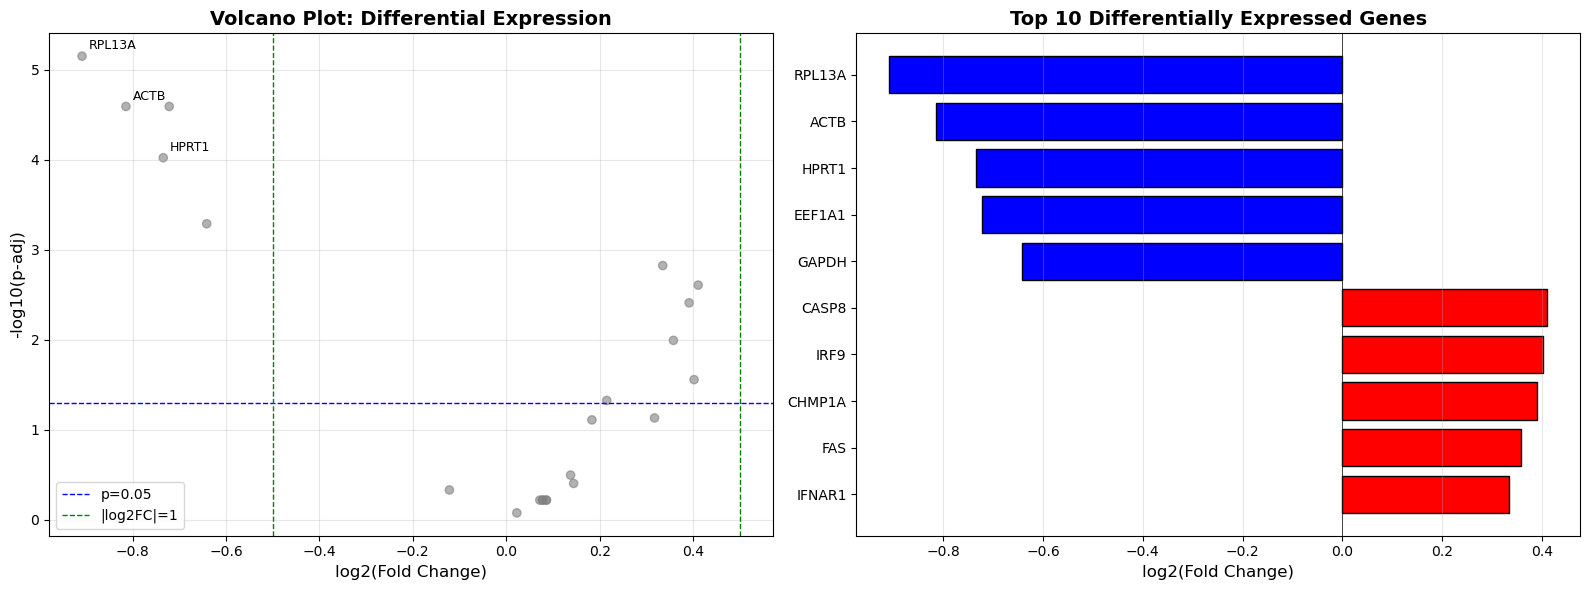

In [62]:
import matplotlib.pyplot as plt
# Create volcano plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volcano plot
ax1 = axes[0]
colors = ['red' if (p < 0.05 and abs(lfc) > 1) else 'gray' 
          for p, lfc in zip(de_df['padj'], de_df['logFC'])]
ax1.scatter(de_df['logFC'], -np.log10(de_df['padj']), c=colors, alpha=0.6)
ax1.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1, label='p=0.05')
ax1.axvline(-0.5, color='green', linestyle='--', linewidth=1)
ax1.axvline(0.5, color='green', linestyle='--', linewidth=1, label='|log2FC|=1')
ax1.set_xlabel('log2(Fold Change)', fontsize=12)
ax1.set_ylabel('-log10(p-adj)', fontsize=12)
ax1.set_title('Volcano Plot: Differential Expression', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Annotate top 3 genes
for idx in range(min(3, len(de_df))):
    gene = de_df.iloc[idx]['gene']
    x = de_df.iloc[idx]['logFC']
    y = -np.log10(de_df.iloc[idx]['padj'])
    ax1.annotate(gene, (x, y), fontsize=9, xytext=(5, 5), textcoords='offset points')

# Bar plot of top 10 genes
ax2 = axes[1]
top_10 = de_df.head(10)
colors_bar = ['red' if lfc > 0 else 'blue' for lfc in top_10['logFC']]
ax2.barh(range(len(top_10)), top_10['logFC'], color=colors_bar, edgecolor='black')
ax2.set_yticks(range(len(top_10)))
ax2.set_yticklabels(top_10['gene'])
ax2.set_xlabel('log2(Fold Change)', fontsize=12)
ax2.set_title('Top 10 Differentially Expressed Genes', fontsize=14, fontweight='bold')
ax2.axvline(0, color='black', linewidth=0.5)
ax2.invert_yaxis()
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Data Classification


In [64]:
# Transpose data (samples as rows, genes as columns)
data_T = log_cpm.T

# Create labels (0 = healthy, 1 = apoptotic)
labels = pd.Series([0]*len(healthy_cols) + [1]*len(apoptotic_cols), 
                   index=data_T.index, name='class')

# Combine features and labels
dataset = pd.concat([labels, data_T], axis=1)

dataset.tail()

,class,GAPDH,ACTB,RPL13A,EEF1A1,HPRT1,CASP3,CASP8,BAX,BCL2,...,TRADD,TNFRSF10B,JAK1,JAK3,STAT4,IRF9,CHMP1A,CHMP5,IFNAR1,VDAC2
apoptotic_16,1,14.946721,14.554418,14.461313,14.641877,14.361781,16.139341,15.876310,15.839785,15.598781,...,15.683668,15.412372,15.508585,15.508585,15.911933,15.946698,15.980645,15.077962,15.013833,15.013833
apoptotic_17,1,14.629672,14.214654,15.629644,15.008171,14.395217,15.261920,15.799565,16.008149,15.799565,...,15.115083,15.593118,15.767145,15.733978,14.951589,15.165707,16.165688,15.165707,16.008149,15.665267
apoptotic_18,1,14.999057,14.620559,14.468562,14.758057,14.620559,15.724865,15.942452,15.620530,15.508058,...,15.546531,15.724865,15.790452,15.883560,15.386070,15.724865,14.690945,15.656153,16.053482,15.546531
apoptotic_19,1,14.148416,13.663021,14.984882,14.510968,14.864592,15.588938,15.832859,15.662937,15.247909,...,15.510937,15.925967,15.698561,15.800438,15.428477,15.698561,16.095890,15.510937,15.385409,15.626412
apoptotic_20,1,13.595402,14.080795,14.665730,15.080754,14.796970,16.028266,15.595314,15.796944,15.443314,...,15.945805,15.699649,15.917237,15.402673,15.858344,15.443314,15.360854,14.973842,15.521315,15.888091


In [81]:
# Shuffle the dataset
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shape: {dataset.shape}")
print(f"\nClass distribution:")
print(dataset['class'].value_counts().sort_index())
print(f"\nClass balance: {(dataset['class']==0).sum()}/{(dataset['class']==1).sum()} (Healthy/Apoptotic)")

# Separate features and labels
X = dataset.drop('class', axis=1)
y = dataset['class']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Labels (y) shape: {y.shape}")
print(f"Feature names (genes): {X.columns.tolist()}")

Dataset shape: (40, 23)

Class distribution:
class
0    20
1    20
Name: count, dtype: int64

Class balance: 20/20 (Healthy/Apoptotic)

Features (X) shape: (40, 22)
Labels (y) shape: (40,)
Feature names (genes): ['GAPDH', 'ACTB', 'RPL13A', 'EEF1A1', 'HPRT1', 'CASP3', 'CASP8', 'BAX', 'BCL2', 'FAS', 'FASLG', 'XIAP', 'TRADD', 'TNFRSF10B', 'JAK1', 'JAK3', 'STAT4', 'IRF9', 'CHMP1A', 'CHMP5', 'IFNAR1', 'VDAC2']


## Feature Selection Strategies

We'll compare three feature selection strategies:
1. **All genes** 
2. **Significantly DE genes** (padj<0.05, |logFC|>0.5)
3. **Top genes** by fold change (10)

In [66]:
print("Strategy 1: Use ALL genes")
X_all = X.copy()
print(f"  Number of features: {X_all.shape[1]}")

Strategy 1: Use ALL genes
  Number of features: 22


In [67]:
print("\nStrategy 2: Use significantly DE genes only")
if len(significant_genes) > 0:
    X_de = X[significant_genes].copy()
    print(f"  Number of features: {X_de.shape[1]}")
    print(f"  Selected genes: {significant_genes}")
else:
    print("  No significantly DE genes found. Using all genes.")
    X_de = X_all.copy()




Strategy 2: Use significantly DE genes only
  Number of features: 5
  Selected genes: ['RPL13A', 'ACTB', 'HPRT1', 'EEF1A1', 'GAPDH']


In [68]:
print("\nStrategy 3: Use top 10 genes by |log2FC|")
top_genes = de_df.head(10)['gene'].tolist()
X_top = X[top_genes].copy()
print(f"  Number of features: {X_top.shape[1]}")
print(f"  Selected genes: {top_genes}")


Strategy 3: Use top 10 genes by |log2FC|
  Number of features: 10
  Selected genes: ['RPL13A', 'ACTB', 'HPRT1', 'EEF1A1', 'GAPDH', 'CASP8', 'IRF9', 'CHMP1A', 'FAS', 'IFNAR1']


In [71]:
# Let's use Strategy 2 (DE genes) or Strategy 3 if no significant genes
if len(significant_genes) > 0:
    X_selected = X_de
    selected_genes = significant_genes
    strategy_name = "Significantly DE genes"
else:
    X_selected = X_top
    selected_genes = top_genes
    strategy_name = "Top 10 genes by fold change"

print(f"\nUsing {strategy_name} for classification")
print(f"Number of features: {X_selected.shape[1]}")


Using Significantly DE genes for classification
Number of features: 5


## Assess if PCA is Needed

check the sample-to-feature ratio to determine if dimensionality reduction is necessary.

In [70]:
n_samples = X_selected.shape[0]
n_features = X_selected.shape[1]
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")
print(f"Ratio (samples/features): {n_samples/n_features:.2f}")

print("\nFeatures << Samples: Low risk of overfitting")

print("\n PCA is not really necessary")

Number of samples: 40
Number of features: 5
Ratio (samples/features): 8.00

Features << Samples: Low risk of overfitting

 PCA is not really necessary


## Train-Test Split

Split data into 70% training and 30% testing with stratification to maintain class balance.

In [39]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(f"  Healthy: {(y_train==0).sum()}")
print(f"  Apoptotic: {(y_train==1).sum()}")
print(f"\nTesting class distribution:")
print(f"  Healthy: {(y_test==0).sum()}")
print(f"  Apoptotic: {(y_test==1).sum()}")

Training set: 28 samples
Testing set: 12 samples

Training class distribution:
  Healthy: 14
  Apoptotic: 14

Testing class distribution:
  Healthy: 6
  Apoptotic: 6


## Feature Scaling

Standardize features to have mean=0 and std=1 (required for SVM and beneficial for most algorithms).

In [72]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized (mean=0, std=1)")
print(f"Training data - mean: {X_train_scaled.mean():.2f}, std: {X_train_scaled.std():.2f}")

Features standardized (mean=0, std=1)
Training data - mean: -0.00, std: 1.00


## PCA Analysis

Perform PCA for visualization

In [73]:
# PCA based visualization
pca_viz = PCA(n_components=min(n_features, n_samples-1), random_state=42)
X_train_pca_viz = pca_viz.fit_transform(X_train_scaled)
X_test_pca_viz = pca_viz.transform(X_test_scaled)
    
print(f"Variance explained by first 5 PCs:")
for i in range(min(5, len(pca_viz.explained_variance_ratio_))):
     print(f"  PC{i+1}: {pca_viz.explained_variance_ratio_[i]:.4f}")
print(f"\nCumulative variance (first 2 PCs): {pca_viz.explained_variance_ratio_[:2].sum():.4f}")
    
# For classification, use optimal number of PCs
n_components = min(n_features, 10)  # Use up to 10 PCs
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
    
print(f"\nFor classification: Using {n_components} principal components")
print(f"Cumulative variance explained: {pca.explained_variance_ratio_.sum():.2f}")


Variance explained by first 5 PCs:
  PC1: 0.5342
  PC2: 0.1516
  PC3: 0.1360
  PC4: 0.1145
  PC5: 0.0637

Cumulative variance (first 2 PCs): 0.6858

For classification: Using 5 principal components
Cumulative variance explained: 1.00


## Visualize PCA 

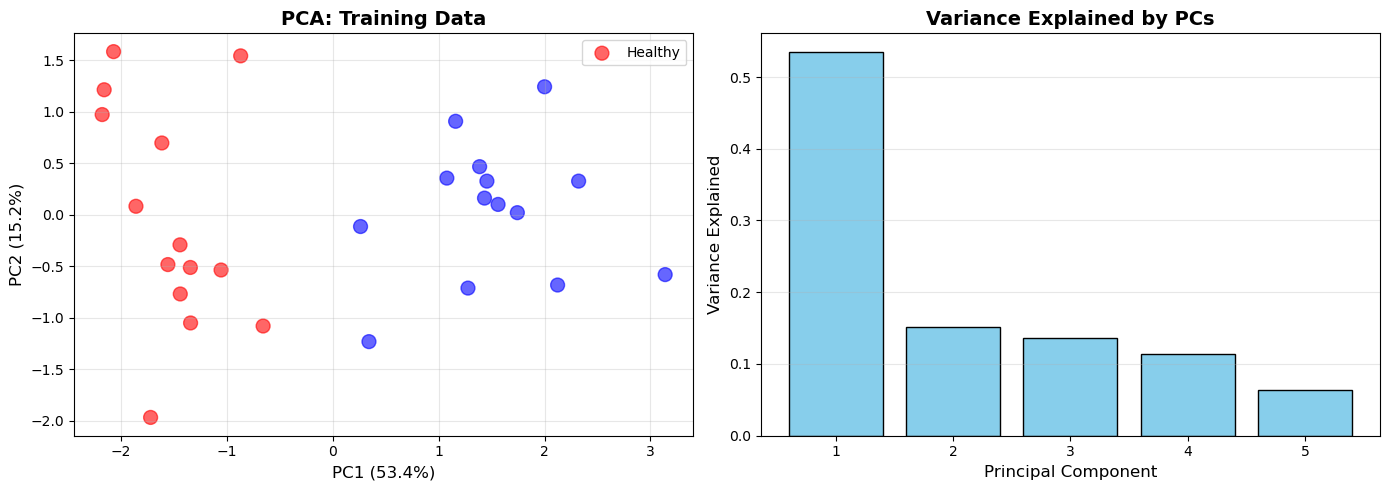

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
# PCA scatter plot
ax1 = axes[0]
colors_pca = ['blue' if label == 0 else 'red' for label in y_train]
ax1.scatter(X_train_pca_viz[:, 0], X_train_pca_viz[:, 1], c=colors_pca, alpha=0.6, s=100)
ax1.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax1.set_title('PCA: Training Data', fontsize=14, fontweight='bold')
ax1.legend(['Healthy', 'Apoptotic'])
ax1.grid(True, alpha=0.3)
    
# Variance explained
ax2 = axes[1]
n_pcs_plot = min(10, len(pca_viz.explained_variance_ratio_))
ax2.bar(range(1, n_pcs_plot + 1), pca_viz.explained_variance_ratio_[:n_pcs_plot],
        color='skyblue', edgecolor='black')
ax2.set_xlabel('Principal Component', fontsize=12)
ax2.set_ylabel('Variance Explained', fontsize=12)
ax2.set_title('Variance Explained by PCs', fontsize=14, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)
    
plt.tight_layout()
plt.show()

## Model Training

**Support Vector Machine (SVM)**

# Support Vector Machine (SVM)

A support vector machine is orthogonal to a linear model - it attempts to find a plane that *separates* the classes of data with the maximum *margin*.

<img  src="http://docs.opencv.org/2.4/_images/optimal-hyperplane.png">

There are two key parameters in an SVM: the kernel and the penalty term (and some kernels may have additional parameters).

# SVM Kernels

A kernel function, $\phi$, is a transformation of the input data that let's us apply SVM (linear separation) to problems that are not linearly separable.

<img src="http://upload.wikimedia.org/wikipedia/commons/1/1b/Kernel_Machine.png">

In [79]:
# SVM without PCA
print("Training SVM (RBF kernel)...")
svm_no_pca = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

y_pred_svm_no_pca = svm_no_pca.predict(X_test_scaled)
y_pred_proba_svm_no_pca = svm_no_pca.predict_proba(X_test_scaled)[:, 1]

svm_acc_no_pca = accuracy_score(y_test, y_pred_svm_no_pca)
svm_auc_no_pca = roc_auc_score(y_test, y_pred_proba_svm_no_pca)

print(f"SVM Accuracy: {svm_acc_no_pca:.4f}")
print(f"SVM AUC-ROC: {svm_auc_no_pca:.4f}")


Training SVM (RBF kernel)...
SVM Accuracy: 0.8333
SVM AUC-ROC: 1.0000


## QUIZ

What performance do you get if you do SVM with PCA